# Visualize the Education's Impact Spatially

In [1]:
import os, sys

sys.path.append(os.path.abspath("."))

In [2]:
os.chdir(CURRENT_ADDR := os.path.abspath(".."))

In [3]:
CURRENT_ADDR

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article'

## Impact Package

In [ ]:
import geopandas as gpd
import math
import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import numpy as np
import os, sys
import pandas as pd

from glob import glob
from matplotlib import cm


In [60]:
import LoadDataFromDisk

In [64]:
import importlib
importlib.reload(LoadDataFromDisk)

<module 'LoadDataFromDisk' from '/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article/MLD01e_Code/LoadDataFromDisk.py'>

## Function

In [56]:
def load_spatial_data() -> gpd.GeoDataFrame:
    """
    Load and combine Nepal EcoBelt and Province spatial data.

    This function:
    1. Loads the EcoBelt shapefile (3-class version: Mountain, Hill, Terai).
    2. Loads the Province shapefile.
    3. Converts both to the same CRS (EPSG:4326, WGS84).
    4. Computes the spatial intersection between EcoBelts and Provinces.

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame containing intersected polygons 
                          with both EcoBelt and Province attributes.
    """
    # --- Load EcoBelt shapefile ---
    gdf_eco = gpd.read_file('PrivateData/SpatialMaps/nepal_ecobelt_data/3_class_shape/Ecobelts_3Class.shp')
    gdf_eco = gdf_eco.to_crs(epsg=4326)
    
    # --- Load Province shapefile ---
    gdf_nepal = gpd.read_file('PrivateData/SpatialMaps/02_PROVINCE/PROVINCE.shp')
    gdf_nepal = gdf_nepal[['geometry', 'Province']].to_crs(epsg=4326)
    
    # --- Intersection ---
    try:
        gdf_intersect = gpd.overlay(gdf_eco, gdf_nepal, how='intersection')
    except Exception as e:
        raise RuntimeError(f"❌ Failed to overlay EcoBelt and Province shapefiles: {e}")

    # --- Optional cleanup ---
    gdf_intersect = gdf_intersect.rename(columns={'EcoBelt': 'Eco_Belt'}) if 'EcoBelt' in gdf_intersect.columns else gdf_intersect
    
    print(f"✅ Loaded spatial data with {len(gdf_intersect)} intersected polygons.")
    return gdf_intersect

In [157]:
def build_province_diff_df(
    probs_dictionary: dict[str, pd.DataFrame],
    input_name_list: list[str],
    province_column: pd.Series,
    ecobelt_column: pd.Series
) -> pd.DataFrame:
    """
    Build a DataFrame of mean probability differences (factual - counterfactual)
    across all Province × EcoBelt combinations for each variable in input_name_list.
    
    Args:
        probs_dictionary (dict): Dictionary with factual and counterfactual DataFrames.
        input_name_list (list): List of input variable names (without 'counter' prefix).
        province_column (pd.Series): Province label for each observation.
        ecobelt_column (pd.Series): EcoBelt label for each observation.
    
    Returns:
        pd.DataFrame: A DataFrame where rows are Province–EcoBelt combinations,
                      and columns are input names.
    """
    province_list = sorted(province_column.unique())
    ecobelt_list = sorted(ecobelt_column.unique())
    
    # Create a combined index of Province × EcoBelt
    index_pairs = [(prov, eco) for prov in province_list for eco in ecobelt_list]
    
    # Prepare an empty DataFrame
    df_diff = pd.DataFrame(index=pd.MultiIndex.from_tuples(index_pairs, names=["Province", "EcoBelt"]),
                           columns=input_name_list, dtype=float)
    
    # Convert to arrays once for speed
    prov_arr = province_column.to_numpy()
    eco_arr = ecobelt_column.to_numpy()

    # Main computation
    for input_name in input_name_list:
        factual_df = probs_dictionary[input_name].copy()
        counterfactual_df = probs_dictionary[f'counter{input_name}'].copy()
        
        factual_df['Province'] = prov_arr
        factual_df['EcoBelt'] = eco_arr
        counterfactual_df['Province'] = prov_arr
        counterfactual_df['EcoBelt'] = eco_arr

        for prov, eco in index_pairs:
            mask_factual = (factual_df['Province'] == prov) & (factual_df['EcoBelt'] == eco)
            mask_counter = (counterfactual_df['Province'] == prov) & (counterfactual_df['EcoBelt'] == eco)
            
            if mask_factual.sum() > 0 and mask_counter.sum() > 0:
                diff = counterfactual_df.loc[mask_factual, 'mean'].mean() - factual_df.loc[mask_counter, 'mean'].mean()
            else:
                diff = float('nan')
            
            df_diff.loc[(prov, eco), input_name] = diff

    return df_diff

## Run

In [160]:
if __name__ == '__main__':
    pass

In [161]:
os.makedirs(MLD01e1_RESULTS_ADDR := './MLD01e_Results/MLD01e1_Results', exist_ok=True)

In [162]:
probs_dictionary = LoadDataFromDisk.read_all_probs_df_from_parquet(MLD01e1_RESULTS_ADDR)

In [163]:
input_name_list = ['factual_knowledge_probs', 'factual_awareness_probs', 
                   'factual_action_probs_soilandwater', 'factual_action_probs_riskreduction', 
                   'factual_action_probs_roadimprovement', 'factual_action_probs_communityparticipation']

In [164]:
map_df = load_spatial_data()

✅ Loaded spatial data with 20 intersected polygons.


In [165]:
map_df.columns = ['EcoBelt', "Province", 'geometry']

In [166]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [167]:
province_name = df_all['Prov'].unique().tolist()

In [168]:
df_diff = build_province_diff_df(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    province_column=df_all['Prov'],
    ecobelt_column=df_all['EcoBelt']
)

In [169]:
# Fix inconsistent province name
map_df.loc[map_df['Province'] == 'Sudur Pashchim', 'Province'] = 'Sudurpashchim'

# Set multi-index with Province and EcoBelt
map_df = map_df.set_index(['Province', 'EcoBelt'])

In [170]:
map_diff_df = df_diff.merge(map_df, left_index=True, right_index=True)

In [171]:
map_diff_df = gpd.GeoDataFrame(map_diff_df, geometry='geometry')

In [172]:
map_diff_df.describe()

,factual_knowledge_probs,factual_awareness_probs,factual_action_probs_soilandwater,factual_action_probs_riskreduction,factual_action_probs_roadimprovement,factual_action_probs_communityparticipation
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,0.049595,0.014904,0.010192,0.005690,0.007835,0.009072
std,0.011755,0.008000,0.006314,0.003478,0.008619,0.009036
min,0.032301,0.006621,0.000396,0.001982,0.000232,-0.000741
25%,0.040219,0.009088,0.005679,0.002920,0.001706,0.003845
50%,0.049399,0.012548,0.009877,0.003683,0.003462,0.005865
75%,0.058490,0.015690,0.012325,0.009759,0.013728,0.009703
max,0.071010,0.033980,0.021023,0.010321,0.029982,0.030369


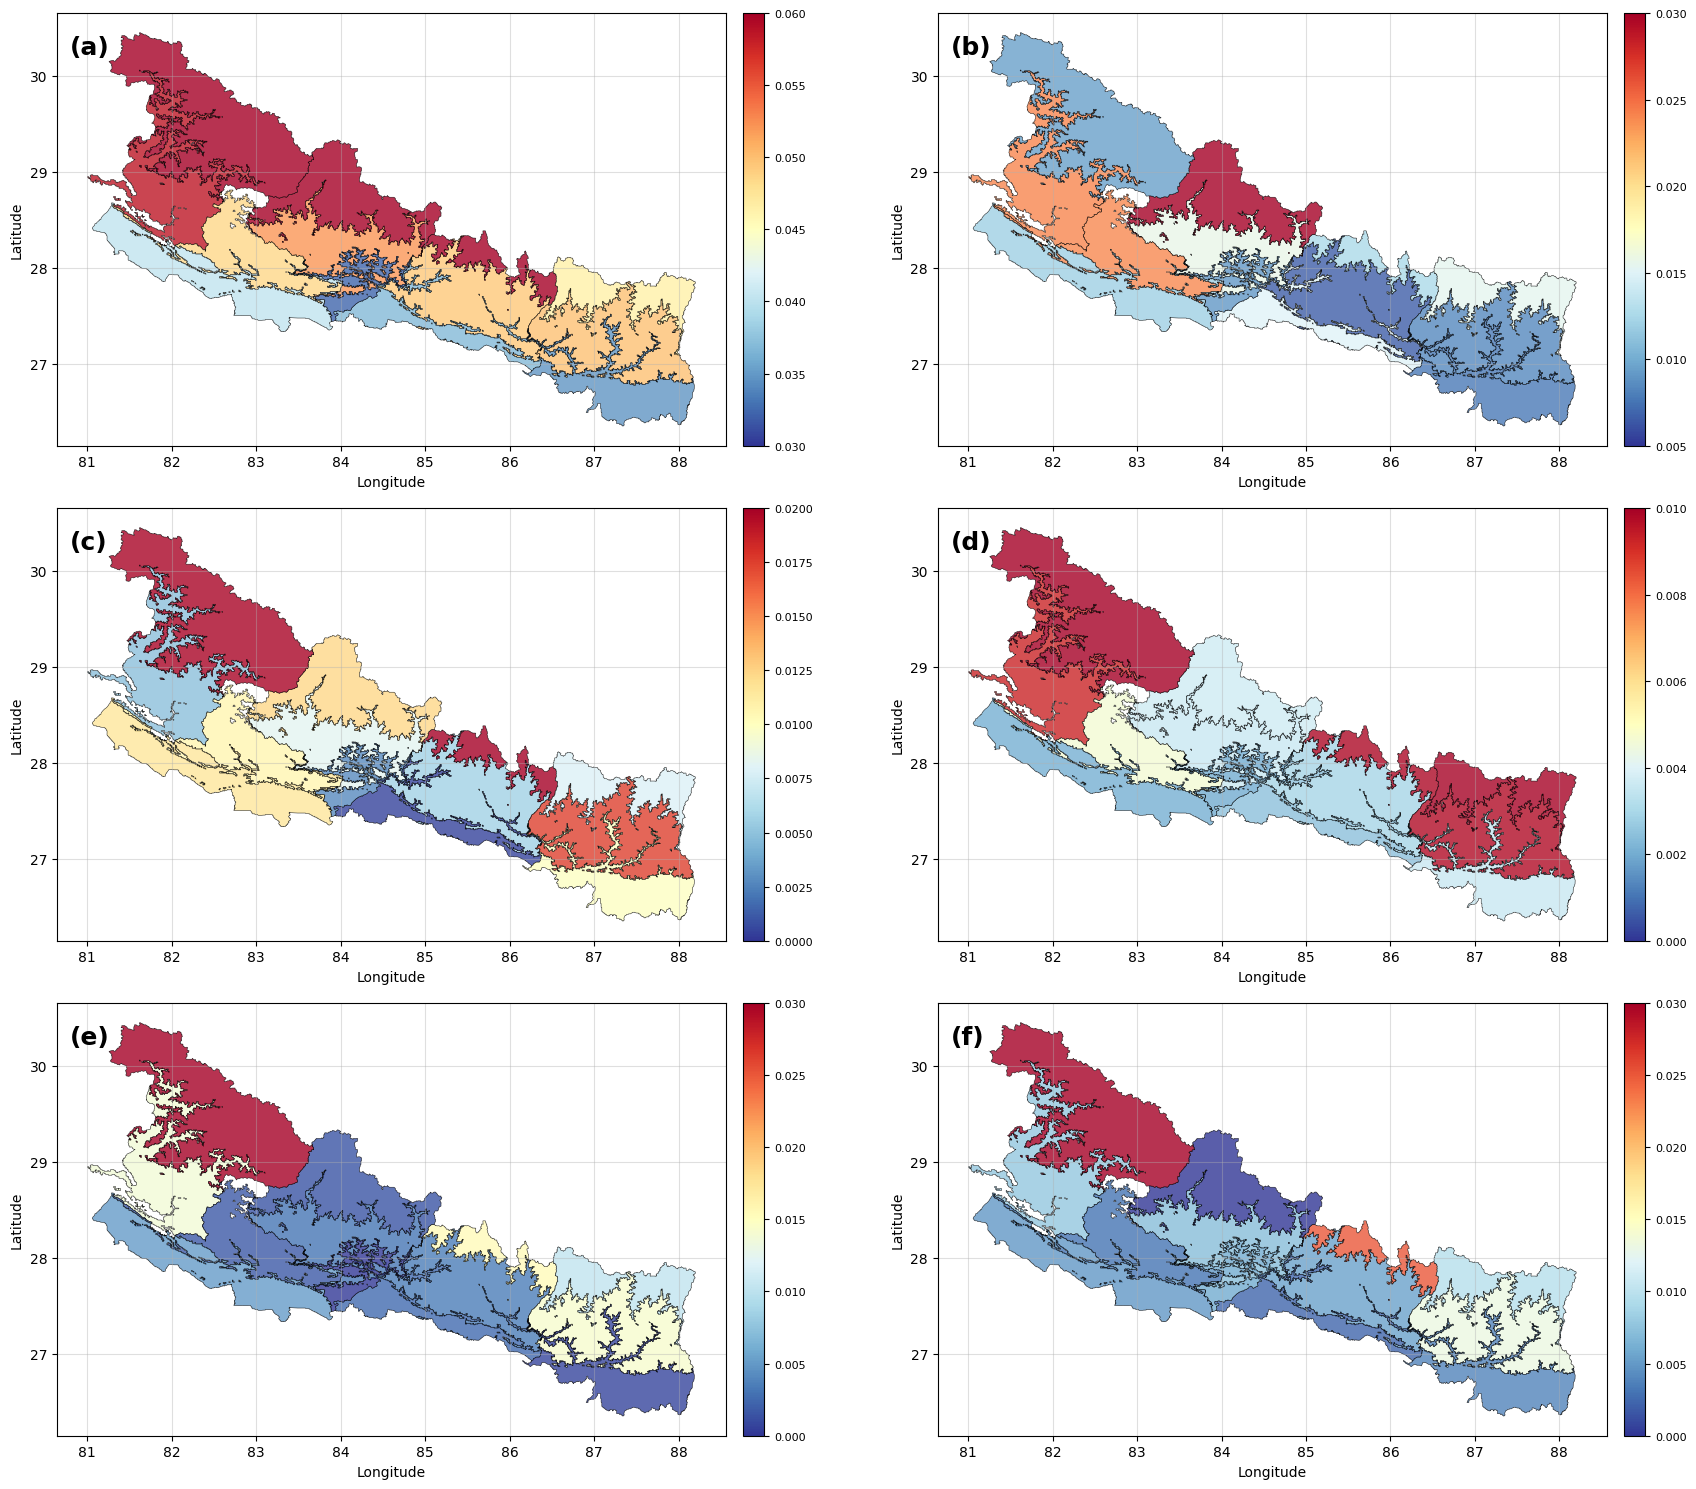

In [ ]:

# Define per-column vmin/vmax
vmaxs = [0.060, 0.030, 0.020, 0.010, 0.030, 0.030]
vmins = [0.030, 0.005, 0, 0, 0, 0]

# Prepare subplots (2 rows × 3 columns)
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten()

# Colormap
cmap = plt.cm.RdYlBu_r
sub_figure_code = list("abcdefghijklmnopqrstuvwxyz")

# Plot each variable
for idx, col in enumerate(map_diff_df.columns[:6]):
    ax = axes[idx]

    # Plot GeoDataFrame without legend
    map_diff_df.plot(
        column=col,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.4,
        vmin=vmins[idx],
        vmax=vmaxs[idx],
        alpha=0.8,
        legend=False,
        ax=ax
    )

    # Create a colorbar manually with matching height
    sm = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=vmins[idx], vmax=vmaxs[idx]),
        cmap=cmap
    )
    sm._A = []  # required for ScalarMappable
    cbar = fig.colorbar(sm, ax=ax, fraction=0.030, pad=0.02)  # adjust height
    cbar.ax.tick_params(labelsize=8)

    # Style
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle='-', alpha=0.4)
    ax.axis('on')
    ax.text(
        0.02, 0.95, f"({sub_figure_code[idx]})",
        transform=ax.transAxes, fontsize=18,
        fontweight='bold', va='top', color='black'
    )
# Remove empty subplot(s)
for ax in axes[len(map_diff_df.columns[:6]):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(save_address, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Violin plots saved to: {save_address}")

### Visualize Senior

In [23]:
print(df_all.columns[:40])

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master', 'Edu_PhD', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year',
       'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio',
       'Literal_Ratio', 'Household_memberNum', 'Own_Resid', 'Resid_Type',
       'WaterS1', 'WaterS2', 'WaterS3', 'CookFuelS1', 'CookFuelS2',
       'CookFuelS3', 'LightEnergy', 'Toilet', 'IncomeS1', 'IncomeS2',
       'IncomeS3', 'Remittance_dummy', 'Have_AgriLand', 'Radio_dummy',
       'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy'],
      dtype='object')


In [39]:
df_all['Prov'].unique()

array(['Koshi', 'Bagmati', 'Madhesh', 'Gandaki', 'Lumbini', 'Karnali',
       'Sudurpaschim'], dtype=object)

In [125]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Respon_Age']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['Above65_Dummy'] = (df_stratification['Respon_Age'] > 65).astype(int)
df_stratification = df_stratification[['Above65_Dummy']]

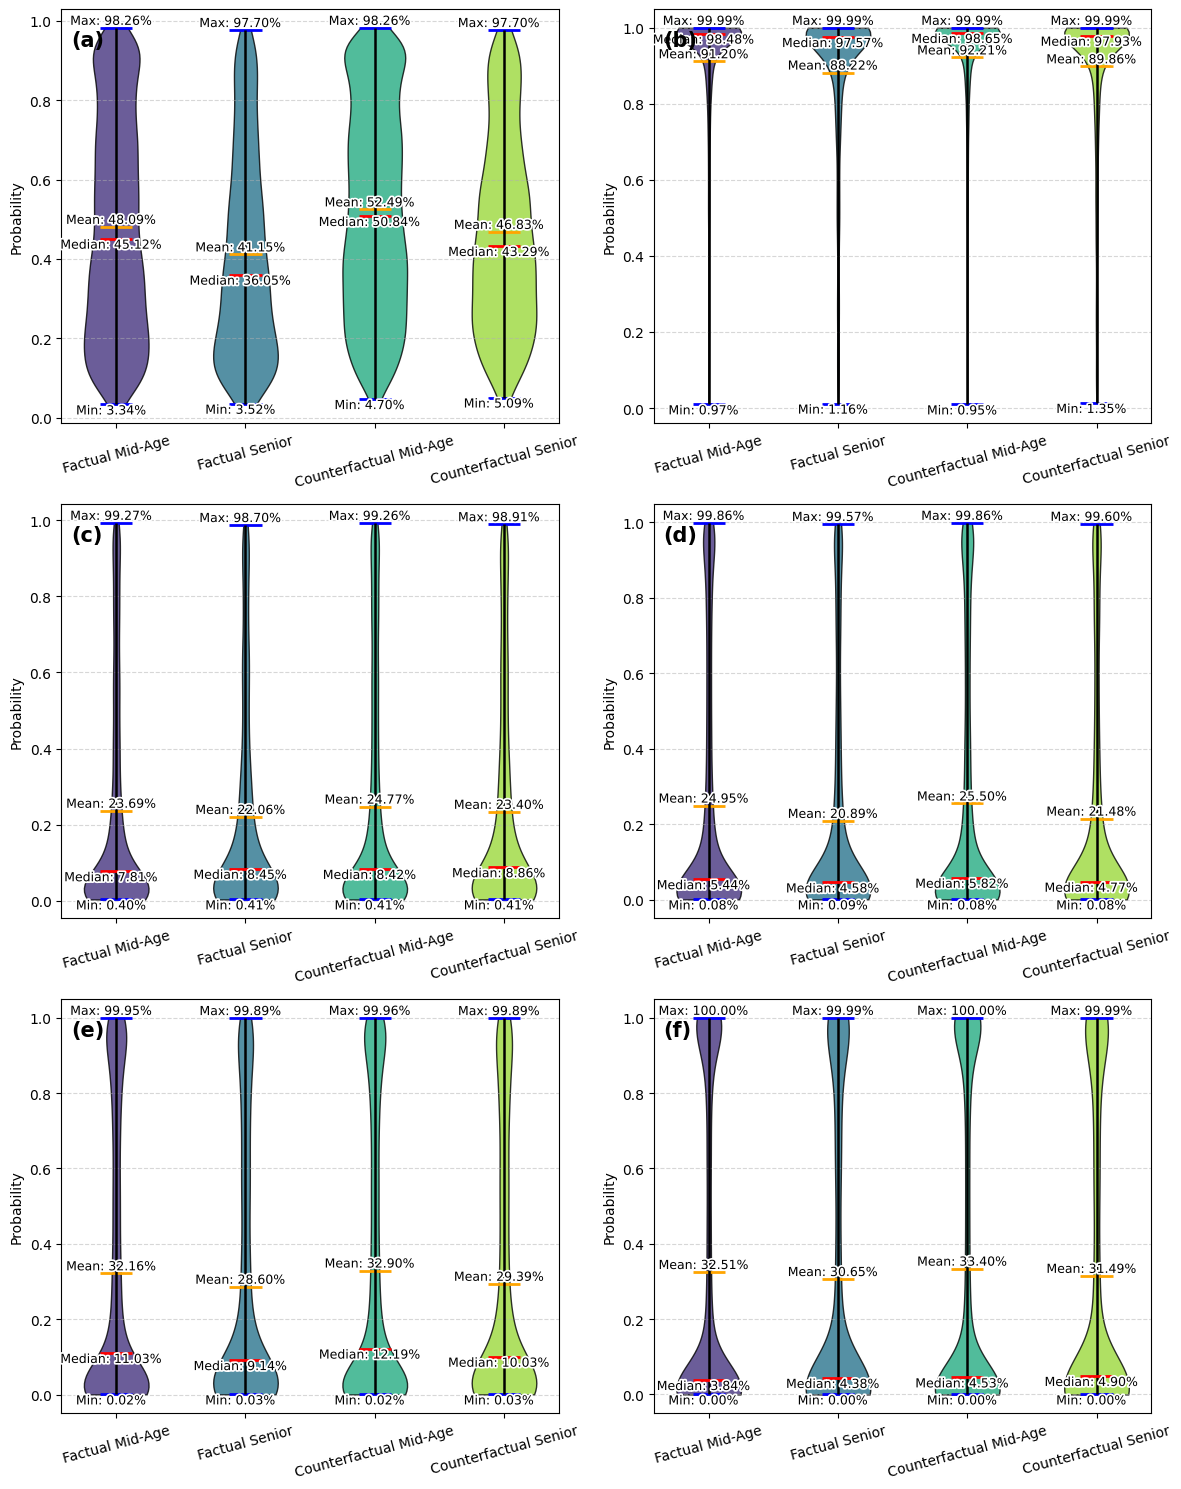

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg


In [126]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Mid-Age', 'Factual Senior', 'Counterfactual Mid-Age', 'Counterfactual Senior'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_senior.jpg'
    )

### Visualize Rural effect

In [130]:
df_stratification = LoadDataFromDisk.load_data_from_disk()[['Rural_Dummy']].reset_index(drop=True)

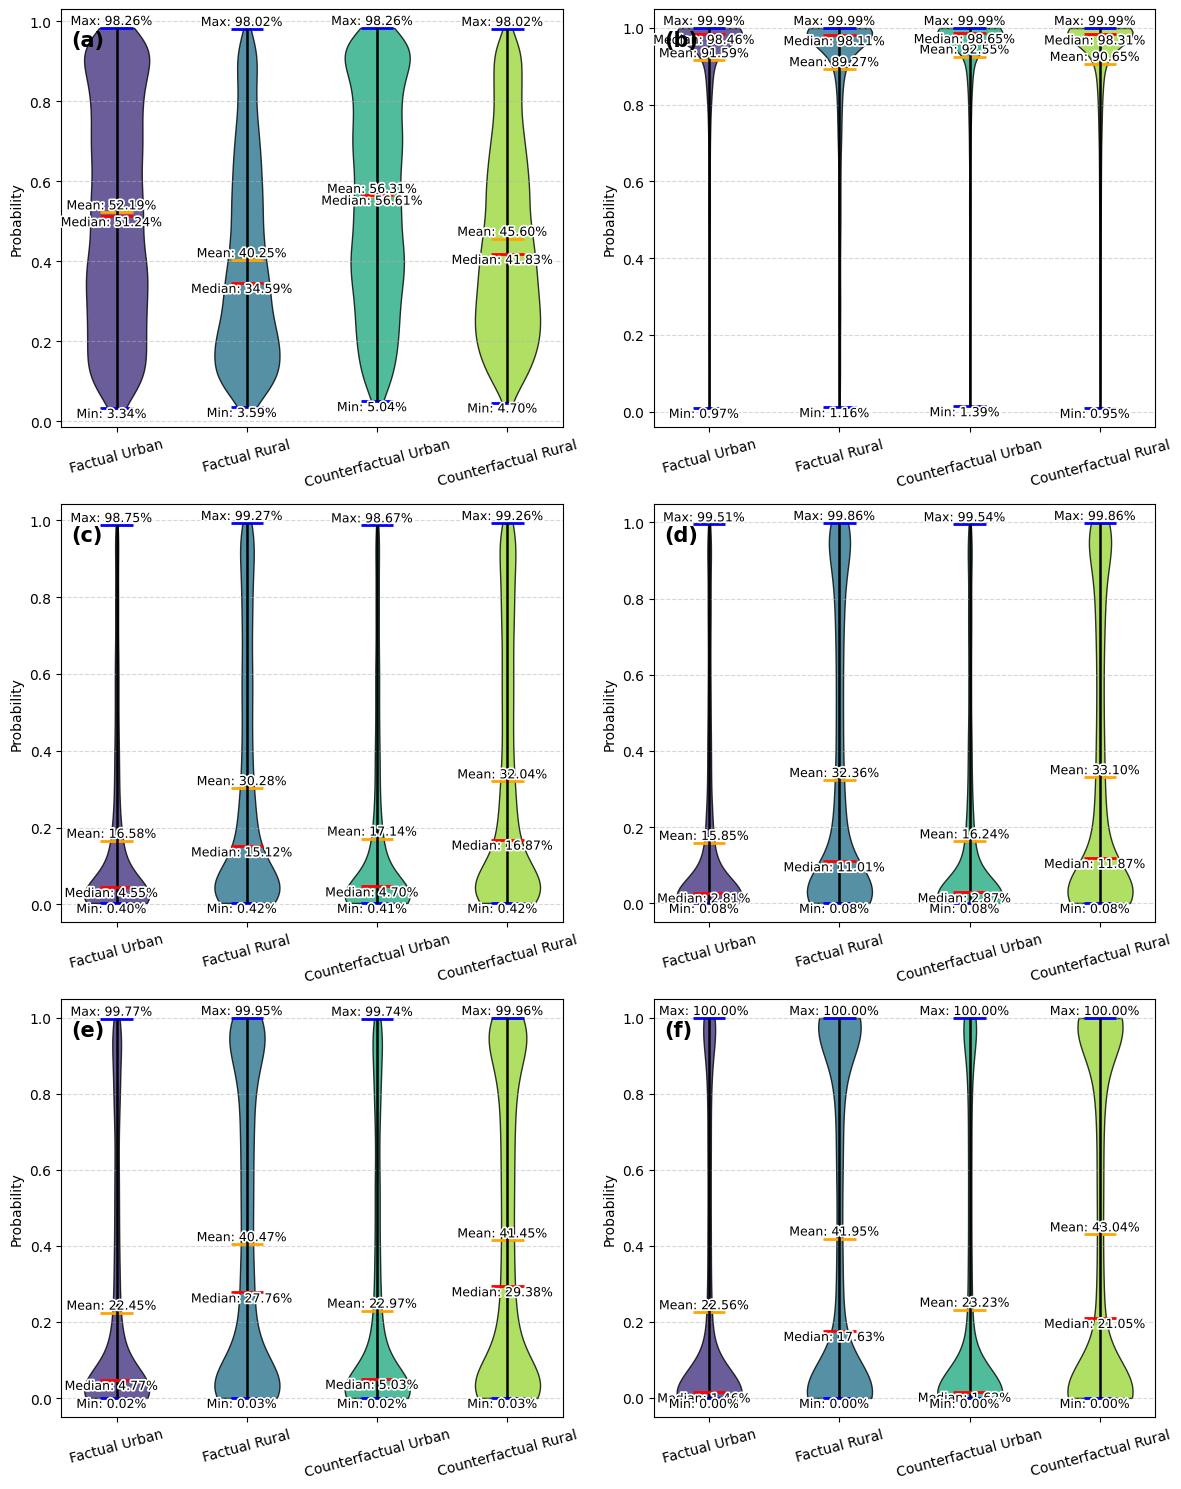

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg


In [131]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Urban', 'Factual Rural', 'Counterfactual Urban', 'Counterfactual Rural'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_rural.jpg'
    )

### Visualize Total Income

In [133]:
df_all = LoadDataFromDisk.load_data_from_disk()

In [136]:
df_all['TotalIncome'].describe()

count    1.156800e+04
mean     3.239423e+05
std      1.143592e+06
min      0.000000e+00
25%      5.400000e+04
50%      1.700000e+05
75%      4.000000e+05
max      9.920000e+07
Name: TotalIncome, dtype: float64

In [140]:
# Load data and keep only Respon_Age
df_stratification = LoadDataFromDisk.load_data_from_disk()[['TotalIncome']].reset_index(drop=True)

# Create dummy: 1 if age > 65, else 0
df_stratification['HighIncome_Dummy'] = (df_stratification['TotalIncome'] > 1.700000e+05).astype(int)
df_stratification = df_stratification[['HighIncome_Dummy']]

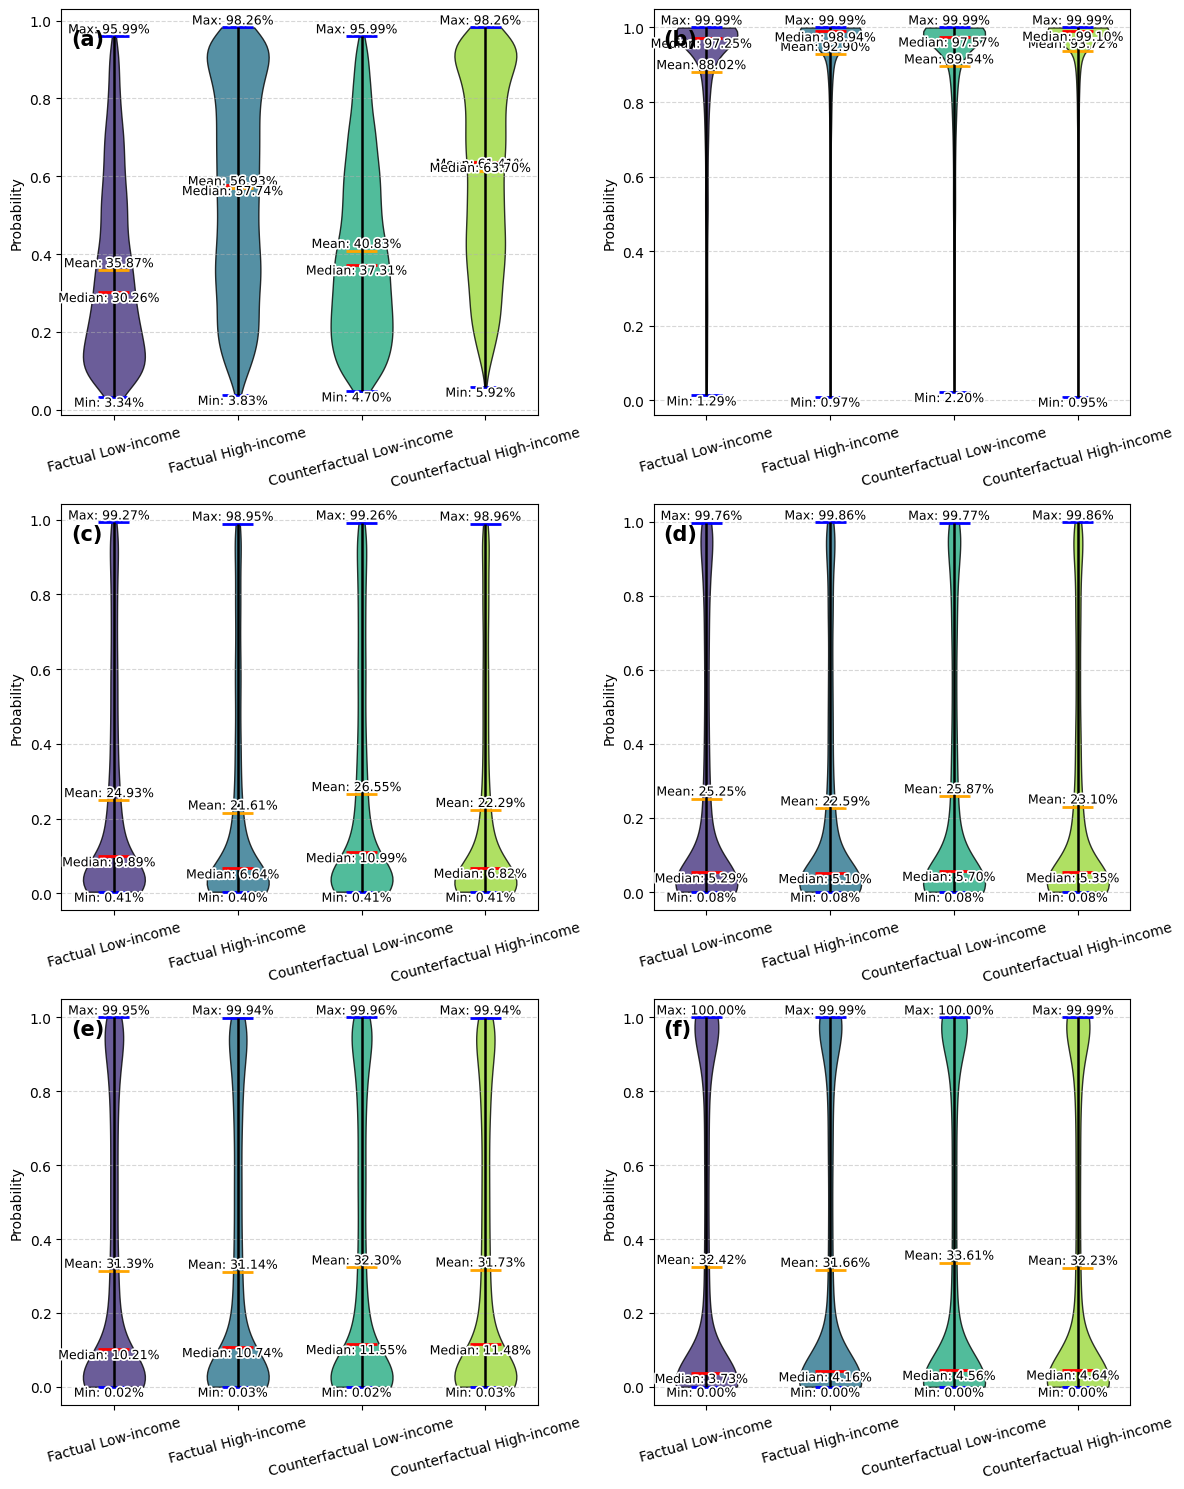

✅ Violin plots saved to: ./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg


In [141]:
visualize_factual_counterfactual_violin_plots_stratification(
    probs_dictionary=probs_dictionary,
    input_name_list=input_name_list,
    df_stratification=df_stratification,
    labels=['Factual Low-income', 'Factual High-income', 'Counterfactual Low-income', 'Counterfactual High-income'],
    save_address='./MLD01e_Figures/FigureXX_factual_counterfactual_violin_stratification_income.jpg'
    )